## 2. Product-specific pricing recommendation

In [7]:
# ============================================================
# PRODUCT-SPECIFIC PRICING RECOMMENDATION
# Start from df_preprocessed.csv
#
# Notes:
# - convert_to_order = 0 means Success
# - convert_to_order = 1 means Fail
# - Do not repeat preprocessing from DataPreprocessing.ipynb
# - Do not drop same quote_id + product + unit_price
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)
sns.set(style="whitegrid")

# ============================================================
# 1. Load preprocessed data
# ============================================================

df = pd.read_csv("../dataset/df_preprocessed.csv")

print("Dataset shape:", df.shape)
display(df.head())

# ============================================================
# 2. Create helper target columns for recommendation
# Original variable is still convert_to_order:
# 0 = Success
# 1 = Fail
# ============================================================

df["success"] = np.where(df["convert_to_order"] == 0, 1, 0)
df["fail"] = np.where(df["convert_to_order"] == 1, 1, 0)

df["conversion_label"] = df["convert_to_order"].map({
    0: "Success",
    1: "Fail"
})

print("Overall success rate:", df["success"].mean() * 100)
display(df["conversion_label"].value_counts())

# ============================================================
# 3. Create product-level summary
# This shows the general performance of each product
# ============================================================

product_summary = df.groupby("product").agg(
    total_rows=("product", "count"),
    total_quote_id=("quote_id", "nunique"),
    success_rate=("success", "mean"),
    fail_rate=("fail", "mean"),
    avg_gmr=("gross_margin_rate", "mean"),
    median_gmr=("gross_margin_rate", "median"),
    avg_unit_price=("unit_price", "mean"),
    avg_qty=("qty", "mean"),
    avg_subtotal_price=("subtotal_price", "mean"),
    avg_energy_grant=("energy_grant_amount", "mean"),
    avg_competitor_price=("avg_competitor_price", "mean"),
    avg_price_gap_pct=("price_gap_avg_competitor_pct", "mean"),
    pct_higher_than_competitor=("higher_than_avg_competitor", "mean"),
    avg_estimated_profit=("estimated_gross_profit", "mean")
).reset_index()

product_summary["success_rate"] = product_summary["success_rate"] * 100
product_summary["fail_rate"] = product_summary["fail_rate"] * 100
product_summary["pct_higher_than_competitor"] = (
    product_summary["pct_higher_than_competitor"] * 100
)

display(product_summary.sort_values("total_rows", ascending=False))

# ============================================================
# 4. Create product-specific margin group
# This is needed only to compare possible pricing ranges per product.
# Negative margin is included for analysis, but not recommended as normal pricing.
# ============================================================

margin_bins = [-np.inf, 0, 0.20, 0.30, 0.40, 0.50, 0.60, np.inf]

margin_labels = [
    "Negative",
    "0-20%",
    "20-30%",
    "30-40%",
    "40-50%",
    "50-60%",
    "60%+"
]

df["margin_group"] = pd.cut(
    df["gross_margin_rate"],
    bins=margin_bins,
    labels=margin_labels
)

display(df[["product", "gross_margin_rate", "margin_group", "convert_to_order", "conversion_label"]].head())

# ============================================================
# 5. Product x margin group summary
# This is the main table for product-specific pricing recommendation
# ============================================================

product_margin_summary = df.groupby(["product", "margin_group"], observed=False).agg(
    total_rows=("product", "count"),
    total_quote_id=("quote_id", "nunique"),
    success_rate=("success", "mean"),
    fail_rate=("fail", "mean"),
    avg_gmr=("gross_margin_rate", "mean"),
    median_gmr=("gross_margin_rate", "median"),
    avg_unit_price=("unit_price", "mean"),
    avg_subtotal_price=("subtotal_price", "mean"),
    avg_energy_grant=("energy_grant_amount", "mean"),
    avg_competitor_price=("avg_competitor_price", "mean"),
    avg_price_gap_pct=("price_gap_avg_competitor_pct", "mean"),
    pct_higher_than_competitor=("higher_than_avg_competitor", "mean"),
    avg_estimated_profit=("estimated_gross_profit", "mean")
).reset_index()

product_margin_summary["success_rate"] = product_margin_summary["success_rate"] * 100
product_margin_summary["fail_rate"] = product_margin_summary["fail_rate"] * 100
product_margin_summary["pct_higher_than_competitor"] = (
    product_margin_summary["pct_higher_than_competitor"] * 100
)

# Expected profit index:
# combines success chance and estimated profit
product_margin_summary["expected_profit_index"] = (
    product_margin_summary["success_rate"] / 100
) * product_margin_summary["avg_estimated_profit"]

display(product_margin_summary.sort_values(["product", "margin_group"]))

# ============================================================
# 6. Keep only reliable product-margin groups
# Adjust thresholds if needed
# ============================================================

MIN_PRODUCT_ROWS = 20
MIN_GROUP_ROWS = 5

reliable_products = product_summary[
    product_summary["total_rows"] >= MIN_PRODUCT_ROWS
]["product"]

reliable_product_margin = product_margin_summary[
    (product_margin_summary["product"].isin(reliable_products)) &
    (product_margin_summary["total_rows"] >= MIN_GROUP_ROWS)
].copy()

display(reliable_product_margin.sort_values(
    ["product", "expected_profit_index"],
    ascending=[True, False]
))

# ============================================================
# 7. Select recommended margin group for each product
# Negative margin is excluded from normal recommendation
# because it is a strategic loss case, not normal pricing.
# ============================================================

normal_margin = reliable_product_margin[
    reliable_product_margin["margin_group"] != "Negative"
].copy()

best_margin_by_product = (
    normal_margin
    .sort_values(
        ["product", "expected_profit_index", "success_rate"],
        ascending=[True, False, False]
    )
    .groupby("product")
    .head(1)
    .reset_index(drop=True)
)

display(best_margin_by_product)

# ============================================================
# 8. Add recommendation notes
# ============================================================

def pricing_recommendation(row):
    success_rate = row["success_rate"]
    margin_group = row["margin_group"]
    price_gap = row["avg_price_gap_pct"]

    if success_rate >= 50 and margin_group in ["20-30%", "30-40%"]:
        return "Recommended: good balance between success rate and margin"
    elif success_rate >= 50 and margin_group == "0-20%":
        return "Competitive, but profitability should be monitored"
    elif success_rate >= 30 and margin_group in ["30-40%", "40-50%"]:
        return "Possible, but conversion risk should be monitored"
    elif success_rate < 20:
        return "Not ideal; high failure risk based on historical data"
    else:
        return "Acceptable, but needs case-by-case review"


def competitor_note(row):
    price_gap = row["avg_price_gap_pct"]

    if pd.isna(price_gap):
        return "Competitor data is limited"
    elif price_gap <= 0:
        return "Generally competitive compared to average competitor price"
    elif price_gap <= 10:
        return "Slightly above competitors; justify with value or service"
    else:
        return "Often above competitors; price review recommended"


best_margin_by_product["pricing_recommendation"] = best_margin_by_product.apply(
    pricing_recommendation,
    axis=1
)

best_margin_by_product["competitor_note"] = best_margin_by_product.apply(
    competitor_note,
    axis=1
)

display(best_margin_by_product[[
    "product",
    "margin_group",
    "total_rows",
    "total_quote_id",
    "success_rate",
    "fail_rate",
    "avg_gmr",
    "avg_unit_price",
    "avg_price_gap_pct",
    "pct_higher_than_competitor",
    "avg_estimated_profit",
    "expected_profit_index",
    "pricing_recommendation",
    "competitor_note"
]].sort_values("expected_profit_index", ascending=False))

Dataset shape: (4991, 35)


,quote_id,product,kw,unit_price,qty,subtotal_price,gross_margin_rate,convert_to_order,energy_grant_amount,competitor_a,competitor_b,competitor_c,price_order,is_highest_price,is_compe_a,is_compe_b,is_compe_c,known_num_compe,avg_compe_price,max_compe_price,min_compe_price,competitor_count_available,avg_competitor_price,min_competitor_price,max_competitor_price,price_gap_avg_competitor,price_gap_avg_competitor_pct,price_gap_min_competitor,price_gap_min_competitor_pct,higher_than_avg_competitor,is_lower_than_competitor,effective_price_after_grant,grant_ratio_to_subtotal,estimated_cost,estimated_gross_profit
0,Q-00114,W,11.00,"136,000.00",1,"136,000.00",0.07,0,66000,NaN,NaN,NaN,1,1,False,False,False,0,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,"70,000.00",0.49,"126,316.80","9,683.20"
1,Q-00119,H1,37.00,"290,000.00",2,"580,000.00",0.31,0,222000,"360,000.00",NaN,NaN,1,1,True,False,False,1,"360,000.00","360,000.00","360,000.00",1,"360,000.00","360,000.00","360,000.00","-70,000.00",-19.44,"-70,000.00",-19.44,0.00,True,"358,000.00",0.38,"401,418.00","178,582.00"
2,Q-00161,Y,150.00,"2,379,000.00",1,"2,379,000.00",0.42,1,720000,NaN,NaN,NaN,1,1,False,False,False,0,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,"1,659,000.00",0.30,"1,374,110.40","1,004,889.60"
3,Q-00167,O1,75.00,"775,970.00",1,"775,970.00",0.41,0,375000,"760,000.00","900,000.00",NaN,1,1,True,True,False,2,"830,000.00","900,000.00","760,000.00",2,"830,000.00","760,000.00","900,000.00","-54,030.00",-6.51,"15,970.00",2.10,0.00,True,"400,970.00",0.48,"456,503.15","319,466.85"
4,Q-00214,I1,22.00,"300,000.00",1,"300,000.00",0.68,0,132000,"240,000.00",NaN,NaN,1,1,True,False,False,1,"240,000.00","240,000.00","240,000.00",1,"240,000.00","240,000.00","240,000.00","60,000.00",25.00,"60,000.00",25.00,1.00,False,"168,000.00",0.44,"96,390.00","203,610.00"


Overall success rate: 25.325586054898817


conversion_label
Fail       3727
Success    1264
Name: count, dtype: int64

,product,total_rows,total_quote_id,success_rate,fail_rate,avg_gmr,median_gmr,avg_unit_price,avg_qty,avg_subtotal_price,avg_energy_grant,avg_competitor_price,avg_price_gap_pct,pct_higher_than_competitor,avg_estimated_profit
17,I1,1531,1449,24.10,75.90,0.41,0.40,"289,635.12",1.25,"338,645.72","132,000.00","240,000.00",20.68,80.86,"140,722.02"
15,H1,1208,1127,30.71,69.29,0.47,0.46,"399,223.24",1.24,"474,900.98","222,000.00","360,000.00",10.90,69.12,"227,163.05"
39,W,651,631,14.29,85.71,0.22,0.20,"192,978.12",1.13,"213,627.19","66,000.00",NaN,NaN,NaN,"50,804.43"
27,N1,404,382,37.13,62.87,0.38,0.34,"744,368.84",1.16,"862,098.98","375,000.00","830,000.00",-10.32,17.33,"346,312.32"
1,A1,360,358,19.44,80.56,0.38,0.32,"267,957.49",1.05,"279,116.17","90,000.00","170,000.00",57.62,99.17,"113,717.78"
32,Q,339,339,10.32,89.68,0.17,0.10,"180,838.22",1.02,"184,512.20","45,000.00","130,000.00",39.11,99.71,"36,655.70"
19,J1,73,72,23.29,76.71,0.36,0.33,"741,761.09",1.27,"880,977.40","181,500.00","620,000.00",19.64,47.95,"323,018.43"
29,O1,62,62,46.77,53.23,0.38,0.33,"741,365.66",1.19,"878,764.40","375,000.00","830,000.00",-10.68,16.13,"349,491.50"
35,S,47,46,17.02,82.98,0.48,0.46,"2,083,735.79",1.11,"2,260,109.83","528,000.00","1,880,000.00",10.84,55.32,"1,142,387.81"
7,D1,28,28,21.43,78.57,0.44,0.41,"3,308,933.79",1.14,"3,655,740.93","960,000.00","2,000,000.00",65.45,100.00,"1,640,070.01"


,product,gross_margin_rate,margin_group,convert_to_order,conversion_label
0,W,0.07,0-20%,0,Success
1,H1,0.31,30-40%,0,Success
2,Y,0.42,40-50%,1,Fail
3,O1,0.41,40-50%,0,Success
4,I1,0.68,60%+,0,Success


,product,margin_group,total_rows,total_quote_id,success_rate,fail_rate,avg_gmr,median_gmr,avg_unit_price,avg_subtotal_price,avg_energy_grant,avg_competitor_price,avg_price_gap_pct,pct_higher_than_competitor,avg_estimated_profit,expected_profit_index
0,A,Negative,1,1,0.00,100.00,-1.32,-1.32,"160,000.00","160,000.00","38,700.00","10,500.00","1,423.81",100.00,"-211,616.00",-0.00
1,A,0-20%,6,6,16.67,83.33,0.15,0.17,"92,466.67","158,600.00","38,700.00","10,500.00",780.63,100.00,"25,710.99","4,285.17"
2,A,20-30%,8,8,25.00,75.00,0.25,0.26,"110,539.00","110,539.00","38,700.00","10,500.00",952.75,100.00,"27,259.37","6,814.84"
3,A,30-40%,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,A,40-50%,3,3,0.00,100.00,0.48,0.48,"160,000.00","160,000.00","38,700.00","10,500.00","1,423.81",100.00,"77,264.00",0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296,Z,20-30%,1,1,100.00,0.00,0.28,0.28,"1,912,200.00","7,648,800.00","720,000.00",NaN,NaN,NaN,"2,160,786.00","2,160,786.00"
297,Z,30-40%,5,5,0.00,100.00,0.35,0.35,"2,125,788.48","2,974,908.42","720,000.00",NaN,NaN,NaN,"1,052,399.00",0.00
298,Z,40-50%,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
299,Z,50-60%,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,product,margin_group,total_rows,total_quote_id,success_rate,fail_rate,avg_gmr,median_gmr,avg_unit_price,avg_subtotal_price,avg_energy_grant,avg_competitor_price,avg_price_gap_pct,pct_higher_than_competitor,avg_estimated_profit,expected_profit_index
2,A,20-30%,8,8,25.00,75.00,0.25,0.26,"110,539.00","110,539.00","38,700.00","10,500.00",952.75,100.00,"27,259.37","6,814.84"
1,A,0-20%,6,6,16.67,83.33,0.15,0.17,"92,466.67","158,600.00","38,700.00","10,500.00",780.63,100.00,"25,710.99","4,285.17"
5,A,50-60%,5,5,0.00,100.00,0.58,0.58,"200,000.00","200,000.00","38,700.00","10,500.00","1,804.76",100.00,"116,860.00",0.00
11,A1,40-50%,9,9,77.78,22.22,0.44,0.44,"255,643.44","255,643.44","90,000.00","170,000.00",50.38,100.00,"111,949.32","87,071.70"
8,A1,0-20%,7,6,100.00,0.00,0.14,0.15,"217,433.02","300,947.31","90,000.00","170,000.00",27.90,71.43,"38,880.88","38,880.88"
9,A1,20-30%,86,85,36.05,63.95,0.28,0.29,"222,697.59","237,452.40","90,000.00","170,000.00",31.00,100.00,"65,481.10","23,603.65"
10,A1,30-40%,157,157,14.65,85.35,0.33,0.32,"236,918.16","248,119.50","90,000.00","170,000.00",39.36,99.36,"81,101.56","11,881.12"
13,A1,60%+,35,35,2.86,97.14,0.61,0.61,"399,534.29","411,105.71","90,000.00","170,000.00",135.02,100.00,"249,866.63","7,139.05"
12,A1,50-60%,66,66,1.52,98.48,0.56,0.56,"338,030.76","338,030.76","90,000.00","170,000.00",98.84,100.00,"190,136.94","2,880.86"
53,D1,40-50%,10,10,20.00,80.00,0.42,0.41,"3,068,092.30","3,068,092.30","960,000.00","2,000,000.00",53.40,100.00,"1,308,341.14","261,668.23"


,product,margin_group,total_rows,total_quote_id,success_rate,fail_rate,avg_gmr,median_gmr,avg_unit_price,avg_subtotal_price,avg_energy_grant,avg_competitor_price,avg_price_gap_pct,pct_higher_than_competitor,avg_estimated_profit,expected_profit_index
0,A,20-30%,8,8,25.00,75.00,0.25,0.26,"110,539.00","110,539.00","38,700.00","10,500.00",952.75,100.00,"27,259.37","6,814.84"
1,A1,40-50%,9,9,77.78,22.22,0.44,0.44,"255,643.44","255,643.44","90,000.00","170,000.00",50.38,100.00,"111,949.32","87,071.70"
2,D1,40-50%,10,10,20.00,80.00,0.42,0.41,"3,068,092.30","3,068,092.30","960,000.00","2,000,000.00",53.40,100.00,"1,308,341.14","261,668.23"
3,H1,50-60%,33,28,72.73,27.27,0.55,0.54,"402,988.67","462,094.73","222,000.00","360,000.00",11.94,78.79,"252,102.06","183,346.95"
4,I1,50-60%,17,15,58.82,41.18,0.55,0.56,"304,750.71","374,698.12","132,000.00","240,000.00",26.98,76.47,"206,657.76","121,563.39"
5,J1,60%+,5,5,20.00,80.00,0.61,0.61,"1,050,800.00","1,162,800.00","181,500.00","620,000.00",69.48,80.00,"709,605.90","141,921.18"
6,N1,20-30%,69,63,75.36,24.64,0.27,0.27,"607,156.98","781,886.49","375,000.00","830,000.00",-26.85,0.00,"208,056.86","156,796.48"
7,O1,40-50%,7,7,71.43,28.57,0.43,0.41,"804,850.74","804,850.74","375,000.00","830,000.00",-3.03,28.57,"346,678.42","247,627.44"
8,Q,20-30%,8,8,50.00,50.00,0.24,0.23,"168,220.00","187,720.00","45,000.00","130,000.00",29.40,100.00,"44,466.06","22,233.03"
9,S,40-50%,12,11,33.33,66.67,0.45,0.46,"1,769,713.33","2,256,778.33","528,000.00","1,880,000.00",-5.87,66.67,"1,036,617.26","345,539.09"


,product,margin_group,total_rows,total_quote_id,success_rate,fail_rate,avg_gmr,avg_unit_price,avg_price_gap_pct,pct_higher_than_competitor,avg_estimated_profit,expected_profit_index,pricing_recommendation,competitor_note
9,S,40-50%,12,11,33.33,66.67,0.45,"1,769,713.33",-5.87,66.67,"1,036,617.26","345,539.09","Possible, but conversion risk should be monitored",Generally competitive compared to average comp...
2,D1,40-50%,10,10,20.00,80.00,0.42,"3,068,092.30",53.40,100.00,"1,308,341.14","261,668.23","Acceptable, but needs case-by-case review",Often above competitors; price review recommended
7,O1,40-50%,7,7,71.43,28.57,0.43,"804,850.74",-3.03,28.57,"346,678.42","247,627.44","Possible, but conversion risk should be monitored",Generally competitive compared to average comp...
3,H1,50-60%,33,28,72.73,27.27,0.55,"402,988.67",11.94,78.79,"252,102.06","183,346.95","Acceptable, but needs case-by-case review",Often above competitors; price review recommended
6,N1,20-30%,69,63,75.36,24.64,0.27,"607,156.98",-26.85,0.00,"208,056.86","156,796.48",Recommended: good balance between success rate...,Generally competitive compared to average comp...
5,J1,60%+,5,5,20.00,80.00,0.61,"1,050,800.00",69.48,80.00,"709,605.90","141,921.18","Acceptable, but needs case-by-case review",Often above competitors; price review recommended
4,I1,50-60%,17,15,58.82,41.18,0.55,"304,750.71",26.98,76.47,"206,657.76","121,563.39","Acceptable, but needs case-by-case review",Often above competitors; price review recommended
1,A1,40-50%,9,9,77.78,22.22,0.44,"255,643.44",50.38,100.00,"111,949.32","87,071.70","Possible, but conversion risk should be monitored",Often above competitors; price review recommended
10,W,30-40%,12,6,25.00,75.00,0.33,"192,186.67",NaN,NaN,"114,597.44","28,649.36","Acceptable, but needs case-by-case review",Competitor data is limited
8,Q,20-30%,8,8,50.00,50.00,0.24,"168,220.00",29.40,100.00,"44,466.06","22,233.03",Recommended: good balance between success rate...,Often above competitors; price review recommended


# New Section

,product,recommended_margin_group,rows_in_recommended_group,quote_ids_in_recommended_group,success_rate_in_recommended_group,fail_rate_in_recommended_group,avg_gmr_in_recommended_group,avg_unit_price_in_recommended_group,avg_price_gap_pct_in_recommended_group,pct_higher_than_competitor_in_recommended_group,avg_estimated_profit_in_recommended_group,expected_profit_index,total_rows_product_overall,total_quote_id_product_overall,success_rate_product_overall,avg_gmr_product_overall,pricing_recommendation,competitor_note
9,S,40-50%,12,11,33.33,66.67,0.45,"1,769,713.33",-5.87,66.67,"1,036,617.26","345,539.09",47,46,17.02,0.48,"Possible, but conversion risk should be monitored",Generally competitive compared to average comp...
2,D1,40-50%,10,10,20.00,80.00,0.42,"3,068,092.30",53.40,100.00,"1,308,341.14","261,668.23",28,28,21.43,0.44,"Acceptable, but needs case-by-case review",Often above competitors; price review recommended
7,O1,40-50%,7,7,71.43,28.57,0.43,"804,850.74",-3.03,28.57,"346,678.42","247,627.44",62,62,46.77,0.38,"Possible, but conversion risk should be monitored",Generally competitive compared to average comp...
3,H1,50-60%,33,28,72.73,27.27,0.55,"402,988.67",11.94,78.79,"252,102.06","183,346.95",1208,1127,30.71,0.47,"Acceptable, but needs case-by-case review",Often above competitors; price review recommended
6,N1,20-30%,69,63,75.36,24.64,0.27,"607,156.98",-26.85,0.00,"208,056.86","156,796.48",404,382,37.13,0.38,Recommended: good balance between success rate...,Generally competitive compared to average comp...
5,J1,60%+,5,5,20.00,80.00,0.61,"1,050,800.00",69.48,80.00,"709,605.90","141,921.18",73,72,23.29,0.36,"Acceptable, but needs case-by-case review",Often above competitors; price review recommended
4,I1,50-60%,17,15,58.82,41.18,0.55,"304,750.71",26.98,76.47,"206,657.76","121,563.39",1531,1449,24.10,0.41,"Acceptable, but needs case-by-case review",Often above competitors; price review recommended
1,A1,40-50%,9,9,77.78,22.22,0.44,"255,643.44",50.38,100.00,"111,949.32","87,071.70",360,358,19.44,0.38,"Possible, but conversion risk should be monitored",Often above competitors; price review recommended
10,W,30-40%,12,6,25.00,75.00,0.33,"192,186.67",NaN,NaN,"114,597.44","28,649.36",651,631,14.29,0.22,"Acceptable, but needs case-by-case review",Competitor data is limited
8,Q,20-30%,8,8,50.00,50.00,0.24,"168,220.00",29.40,100.00,"44,466.06","22,233.03",339,339,10.32,0.17,Recommended: good balance between success rate...,Often above competitors; price review recommended


,product,total_rows,total_quote_id,success_rate,fail_rate,avg_gmr,median_gmr,avg_unit_price,avg_qty,avg_subtotal_price,avg_energy_grant,avg_competitor_price,avg_price_gap_pct,pct_higher_than_competitor,avg_estimated_profit,recommendation_note
3,B1,1,1,0.00,100.00,0.66,0.66,"3,752,700.00",1.00,"3,752,700.00","768,000.00",NaN,NaN,NaN,"2,485,413.21",Not enough data for product-specific recommend...
14,H,1,1,0.00,100.00,0.57,0.57,"2,008,010.00",1.00,"2,008,010.00","820,000.00",NaN,NaN,NaN,"1,146,172.11",Not enough data for product-specific recommend...
13,G1,1,1,100.00,0.00,0.43,0.43,"2,806,000.00",1.00,"2,806,000.00","960,000.00","2,000,000.00",40.30,100.00,"1,198,723.20",Not enough data for product-specific recommend...
22,L,1,1,100.00,0.00,0.04,0.04,"300,600.00",2.00,"601,200.00","236,500.00",NaN,NaN,NaN,"21,162.24",Not enough data for product-specific recommend...
21,K1,3,3,0.00,100.00,0.44,0.39,"830,838.00",1.00,"830,838.00","181,500.00","620,000.00",34.01,66.67,"402,912.46",Not enough data for product-specific recommend...
10,F,3,3,33.33,66.67,0.53,0.53,"2,462,833.33",1.67,"4,079,666.67","615,000.00",NaN,NaN,NaN,"2,244,321.60",Not enough data for product-specific recommend...
30,P,3,3,33.33,66.67,0.23,0.27,"851,887.33",1.00,"851,887.33","322,500.00",NaN,NaN,NaN,"196,442.66",Not enough data for product-specific recommend...
23,L1,4,4,50.00,50.00,0.38,0.34,"1,050,423.25",1.50,"1,526,771.50","181,500.00","620,000.00",69.42,100.00,"569,327.08",Not enough data for product-specific recommend...
5,C1,5,5,100.00,0.00,0.28,0.15,"1,331,799.75",1.40,"1,927,707.50","768,000.00","2,100,000.00",-36.58,0.00,"585,816.60",Not enough data for product-specific recommend...
8,E,5,4,20.00,80.00,0.58,0.60,"376,349.82",1.00,"376,349.82","48,600.00",NaN,NaN,NaN,"223,964.20",Not enough data for product-specific recommend...


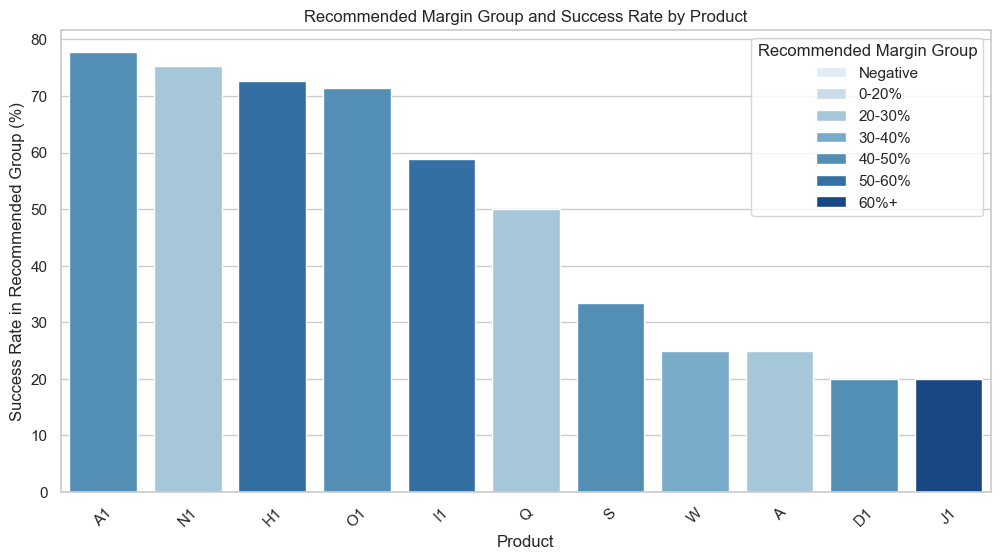

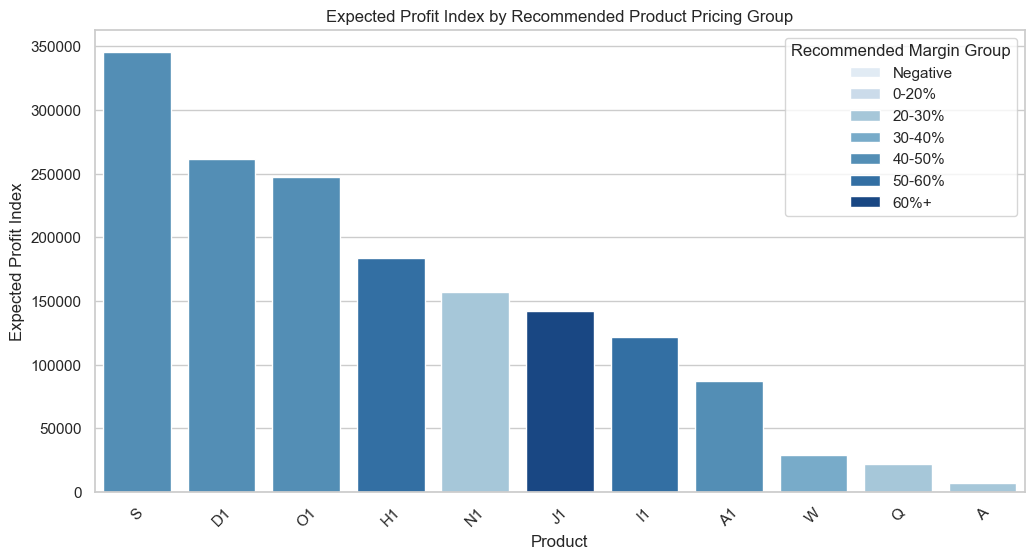

Output saved as: ../outputs/product_specific_pricing_recommendation.xlsx


In [8]:
# ============================================================
# 9. Final recommendation table
# ============================================================

final_recommendation = best_margin_by_product.merge(
    product_summary,
    on="product",
    how="left",
    suffixes=("_recommended", "_overall")
)

final_table = final_recommendation[[
    "product",
    "margin_group",
    "total_rows_recommended",
    "total_quote_id_recommended",
    "success_rate_recommended",
    "fail_rate_recommended",
    "avg_gmr_recommended",
    "avg_unit_price_recommended",
    "avg_price_gap_pct_recommended",
    "pct_higher_than_competitor_recommended",
    "avg_estimated_profit_recommended",
    "expected_profit_index",
    "total_rows_overall",
    "total_quote_id_overall",
    "success_rate_overall",
    "avg_gmr_overall",
    "pricing_recommendation",
    "competitor_note"
]].copy()

final_table = final_table.rename(columns={
    "margin_group": "recommended_margin_group",
    "total_rows_recommended": "rows_in_recommended_group",
    "total_quote_id_recommended": "quote_ids_in_recommended_group",
    "success_rate_recommended": "success_rate_in_recommended_group",
    "fail_rate_recommended": "fail_rate_in_recommended_group",
    "avg_gmr_recommended": "avg_gmr_in_recommended_group",
    "avg_unit_price_recommended": "avg_unit_price_in_recommended_group",
    "avg_price_gap_pct_recommended": "avg_price_gap_pct_in_recommended_group",
    "pct_higher_than_competitor_recommended": "pct_higher_than_competitor_in_recommended_group",
    "avg_estimated_profit_recommended": "avg_estimated_profit_in_recommended_group",
    "total_rows_overall": "total_rows_product_overall",
    "total_quote_id_overall": "total_quote_id_product_overall",
    "success_rate_overall": "success_rate_product_overall",
    "avg_gmr_overall": "avg_gmr_product_overall"
})

display(final_table.sort_values("expected_profit_index", ascending=False))

# ============================================================
# 10. Products with insufficient data
# ============================================================

insufficient_products = product_summary[
    product_summary["total_rows"] < MIN_PRODUCT_ROWS
].copy()

insufficient_products["recommendation_note"] = (
    "Not enough data for product-specific recommendation. "
    "Use general pricing strategy or collect more data."
)

display(insufficient_products.sort_values("total_rows"))

# ============================================================
# Set color palette for margin groups
# Lightest = Negative margin
# Darker = higher margin group
# ============================================================

margin_palette = {
    "Negative": "#DEEBF7",   # lightest blue
    "0-20%": "#C6DBEF",
    "20-30%": "#9ECAE1",
    "30-40%": "#6BAED6",
    "40-50%": "#4292C6",
    "50-60%": "#2171B5",
    "60%+": "#084594"        # darkest blue
}

margin_order = [
    "Negative",
    "0-20%",
    "20-30%",
    "30-40%",
    "40-50%",
    "50-60%",
    "60%+"
]

# ============================================================
# 11. Visualization: recommended margin group by product
# ============================================================

plot_df = final_table.sort_values(
    "success_rate_in_recommended_group",
    ascending=False
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=plot_df,
    x="product",
    y="success_rate_in_recommended_group",
    hue="recommended_margin_group",
    hue_order=margin_order,
    palette=margin_palette,
    order=plot_df["product"].tolist()
)

plt.title("Recommended Margin Group and Success Rate by Product")
plt.xlabel("Product")
plt.ylabel("Success Rate in Recommended Group (%)")
plt.xticks(rotation=45)
plt.legend(title="Recommended Margin Group")
plt.show()

# ============================================================
# 12. Visualization: recommended margin group by product
# ============================================================

plot_df_profit = final_table.sort_values("expected_profit_index", ascending=False)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=plot_df_profit,
    x="product",
    y="expected_profit_index",
    hue="recommended_margin_group",
    hue_order=margin_order,
    palette=margin_palette
)

plt.title("Expected Profit Index by Recommended Product Pricing Group")
plt.xlabel("Product")
plt.ylabel("Expected Profit Index")
plt.xticks(rotation=45)
plt.legend(title="Recommended Margin Group")
plt.show()

# ============================================================
# 13. Save output
# ============================================================

output_file = "../outputs/product_specific_pricing_recommendation.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    product_summary.to_excel(writer, sheet_name="Product_Summary", index=False)
    product_margin_summary.to_excel(writer, sheet_name="Product_Margin_Summary", index=False)
    reliable_product_margin.to_excel(writer, sheet_name="Reliable_Product_Margin", index=False)
    final_table.to_excel(writer, sheet_name="Final_Recommendation", index=False)
    insufficient_products.to_excel(writer, sheet_name="Insufficient_Data", index=False)

print(f"Output saved as: {output_file}")

## 3. Competitor positioning analysis

Dataset shape: (4991, 39)
['quote_id', 'product', 'kw', 'unit_price', 'qty', 'subtotal_price', 'gross_margin_rate', 'convert_to_order', 'energy_grant_amount', 'competitor_a', 'competitor_b', 'competitor_c', 'price_order', 'is_highest_price', 'is_compe_a', 'is_compe_b', 'is_compe_c', 'known_num_compe', 'avg_compe_price', 'max_compe_price', 'min_compe_price', 'competitor_count_available', 'avg_competitor_price', 'min_competitor_price', 'max_competitor_price', 'price_gap_avg_competitor', 'price_gap_avg_competitor_pct', 'price_gap_min_competitor', 'price_gap_min_competitor_pct', 'higher_than_avg_competitor', 'is_lower_than_competitor', 'effective_price_after_grant', 'grant_ratio_to_subtotal', 'estimated_cost', 'estimated_gross_profit', 'success', 'fail', 'conversion_label', 'margin_group']
Average competitor price column: avg_competitor_price
Minimum competitor price column: min_competitor_price
Maximum competitor price column: max_competitor_price


,quote_id,product,unit_price,avg_competitor_price,price_gap_avg_competitor_pct,competitor_position,convert_to_order,conversion_label
0,Q-00114,W,"136,000.00",NaN,NaN,No Competitor Data,0,Success
1,Q-00119,H1,"290,000.00","360,000.00",-19.44,Much Lower than Competitor,0,Success
2,Q-00161,Y,"2,379,000.00",NaN,NaN,No Competitor Data,1,Fail
3,Q-00167,O1,"775,970.00","830,000.00",-6.51,Slightly Lower / Equal,0,Success
4,Q-00214,I1,"300,000.00","240,000.00",25.00,Moderately Higher,0,Success


,competitor_position,total_rows,total_quote_id,success_rate,fail_rate,avg_unit_price,avg_competitor_price,avg_price_gap_pct,median_price_gap_pct,avg_gmr,avg_qty,avg_subtotal_price
2,Much Lower than Competitor,833,670,75.39,24.61,"470,164.95","604,489.80",-22.56,-22.21,0.25,1.73,"676,367.89"
5,Slightly Lower / Equal,321,311,51.40,48.60,"432,109.80","450,965.73",-3.98,-3.04,0.40,1.14,"482,670.74"
4,Slightly Higher,834,820,13.19,86.81,"364,859.86","348,429.26",4.96,5.30,0.44,1.08,"402,698.06"
0,Moderately Higher,1052,1045,10.74,89.26,"307,716.15","262,034.22",16.93,14.07,0.34,1.04,"329,269.63"
1,Much Higher,1121,1108,7.23,92.77,"611,215.54","359,689.12",93.66,75.50,0.53,1.05,"641,479.90"
3,No Competitor Data,830,794,20.12,79.88,"379,600.09",NaN,NaN,NaN,0.24,1.16,"468,054.50"


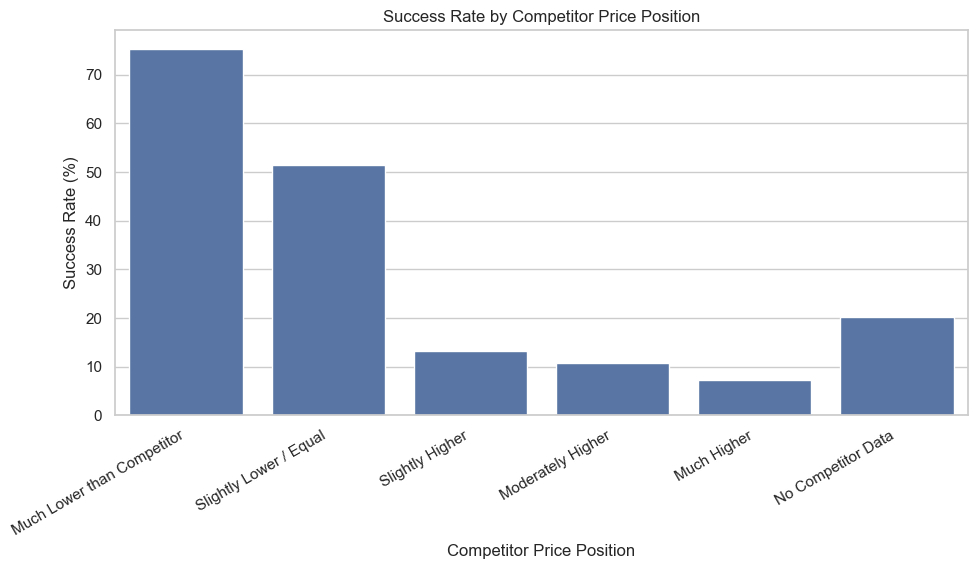

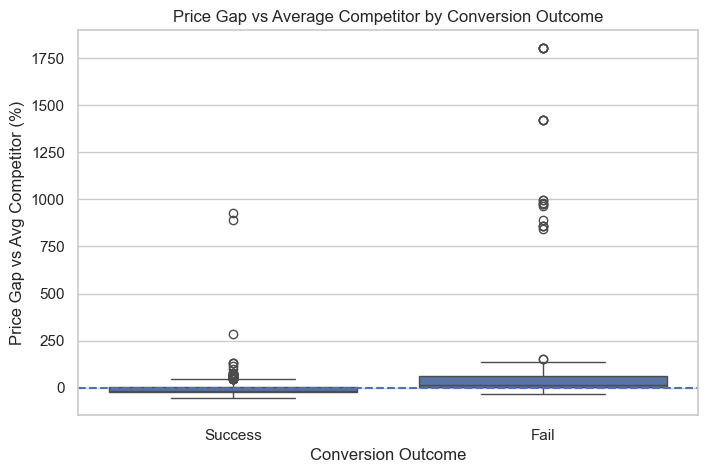

,product,total_rows,total_quote_id,success_rate,avg_unit_price,avg_competitor_price,avg_price_gap_pct,median_price_gap_pct,pct_higher_than_competitor,avg_gmr,avg_qty,avg_subtotal_price
0,A,23,23,13.04,"133,874.43","10,500.00","1,174.99",981.90,100.00,0.26,1.17,"151,126.61"
23,L1,4,4,50.00,"1,050,423.25","620,000.00",69.42,53.66,100.00,0.38,1.50,"1,526,771.50"
11,F1,6,6,33.33,"3,361,052.42","2,000,000.00",68.05,86.30,83.33,0.40,1.17,"3,584,654.83"
7,D1,28,28,21.43,"3,308,933.79","2,000,000.00",65.45,49.50,100.00,0.44,1.14,"3,655,740.93"
25,M1,6,5,33.33,"1,012,843.19","620,000.00",63.36,57.41,100.00,0.42,1.17,"1,127,838.05"
1,A1,360,358,19.44,"267,957.49","170,000.00",57.62,39.37,99.17,0.38,1.05,"279,116.17"
9,E1,17,15,47.06,"3,004,810.59","2,000,000.00",50.24,40.30,82.35,0.32,1.06,"3,148,303.53"
13,G1,1,1,100.00,"2,806,000.00","2,000,000.00",40.30,40.30,100.00,0.43,1.00,"2,806,000.00"
32,Q,339,339,10.32,"180,838.22","130,000.00",39.11,26.00,99.71,0.17,1.02,"184,512.20"
21,K1,3,3,0.00,"830,838.00","620,000.00",34.01,14.32,66.67,0.44,1.00,"830,838.00"


,product,total_rows,total_quote_id,success_rate,avg_unit_price,avg_competitor_price,avg_price_gap_pct,median_price_gap_pct,pct_higher_than_competitor,avg_gmr,avg_qty,avg_subtotal_price
0,A,23,23,13.04,"133,874.43","10,500.00","1,174.99",981.90,100.00,0.26,1.17,"151,126.61"
7,D1,28,28,21.43,"3,308,933.79","2,000,000.00",65.45,49.50,100.00,0.44,1.14,"3,655,740.93"
1,A1,360,358,19.44,"267,957.49","170,000.00",57.62,39.37,99.17,0.38,1.05,"279,116.17"
32,Q,339,339,10.32,"180,838.22","130,000.00",39.11,26.00,99.71,0.17,1.02,"184,512.20"
17,I1,1531,1449,24.10,"289,635.12","240,000.00",20.68,12.12,80.86,0.41,1.25,"338,645.72"
19,J1,73,72,23.29,"741,761.09","620,000.00",19.64,-1.58,47.95,0.36,1.27,"880,977.40"
15,H1,1208,1127,30.71,"399,223.24","360,000.00",10.90,3.24,69.12,0.47,1.24,"474,900.98"
35,S,47,46,17.02,"2,083,735.79","1,880,000.00",10.84,1.69,55.32,0.48,1.11,"2,260,109.83"
27,N1,404,382,37.13,"744,368.84","830,000.00",-10.32,-18.24,17.33,0.38,1.16,"862,098.98"
29,O1,62,62,46.77,"741,365.66","830,000.00",-10.68,-20.73,16.13,0.38,1.19,"878,764.40"


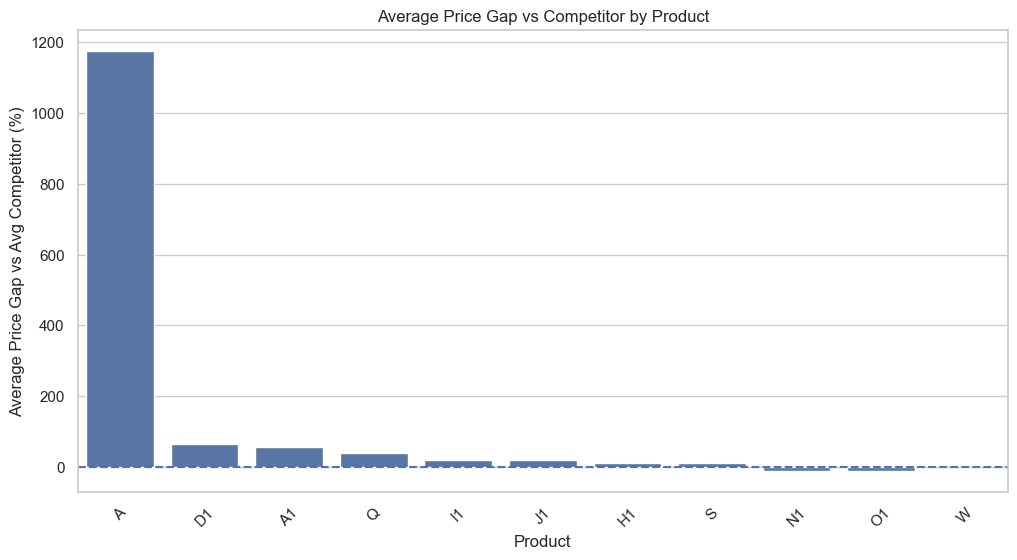

,product,competitor_position,total_rows,total_quote_id,success_rate,fail_rate,avg_unit_price,avg_competitor_price,avg_price_gap_pct,avg_gmr,avg_qty,avg_subtotal_price
0,A,Much Higher,23,23,13.04,86.96,"133,874.43","10,500.00","1,174.99",0.26,1.17,"151,126.61"
1,A1,Moderately Higher,30,30,60.00,40.00,"213,258.17","170,000.00",25.45,0.27,1.13,"242,127.78"
2,A1,Much Higher,325,325,14.46,85.54,"274,845.40","170,000.00",61.67,0.40,1.03,"282,820.63"
3,A1,Much Lower than Competitor,2,2,100.00,0.00,"117,917.50","170,000.00",-30.64,0.20,2.50,"310,460.00"
4,A1,Slightly Higher,2,2,100.00,0.00,"174,480.00","170,000.00",2.64,0.17,1.50,"261,480.00"
...,...,...,...,...,...,...,...,...,...,...,...,...
85,V,Much Lower than Competitor,4,3,100.00,0.00,"1,452,485.00","1,880,000.00",-22.74,0.35,1.00,"1,452,485.00"
86,W,No Competitor Data,651,631,14.29,85.71,"192,978.12",NaN,NaN,0.22,1.13,"213,627.19"
87,X,No Competitor Data,12,10,58.33,41.67,"130,686.32",NaN,NaN,0.21,1.25,"160,441.05"
88,Y,No Competitor Data,11,11,27.27,72.73,"2,295,965.39",NaN,NaN,0.39,1.55,"3,515,612.66"


,product,competitor_position,total_rows,total_quote_id,success_rate,fail_rate,avg_unit_price,avg_competitor_price,avg_price_gap_pct,avg_gmr,avg_qty,avg_subtotal_price
0,A,Much Higher,23,23,13.04,86.96,"133,874.43","10,500.00","1,174.99",0.26,1.17,"151,126.61"
1,A1,Moderately Higher,30,30,60.00,40.00,"213,258.17","170,000.00",25.45,0.27,1.13,"242,127.78"
2,A1,Much Higher,325,325,14.46,85.54,"274,845.40","170,000.00",61.67,0.40,1.03,"282,820.63"
12,D1,Much Higher,25,25,16.00,84.00,"3,412,525.84","2,000,000.00",70.63,0.46,1.04,"3,524,949.84"
28,H1,Much Lower than Competitor,203,140,99.51,0.49,"279,640.98","360,000.00",-22.32,0.29,1.96,"537,184.24"
26,H1,Moderately Higher,26,26,80.77,19.23,"419,768.88","360,000.00",16.60,0.50,1.19,"503,972.73"
30,H1,Slightly Lower / Equal,170,163,44.71,55.29,"350,103.92","360,000.00",-2.75,0.44,1.16,"404,449.18"
29,H1,Slightly Higher,571,565,11.38,88.62,"374,365.66","360,000.00",3.99,0.46,1.06,"397,659.24"
27,H1,Much Higher,238,237,2.94,97.06,"593,697.90","360,000.00",64.92,0.66,1.10,"654,239.08"
34,I1,Much Lower than Competitor,230,161,100.00,0.00,"181,367.45","240,000.00",-24.43,0.12,2.32,"417,993.36"


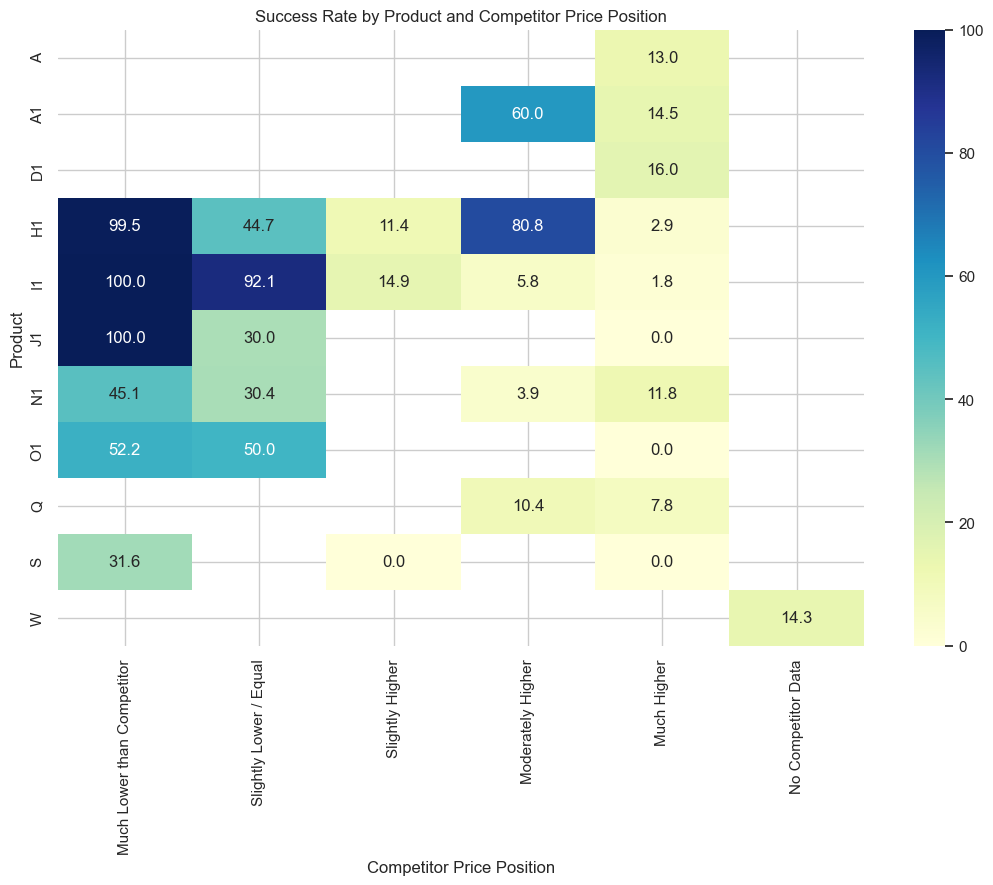

,competitor_position,total_rows,total_quote_id,success_rate,avg_gmr,avg_price_gap_pct
2,Much Lower than Competitor,833,670,75.39,0.25,-22.56
5,Slightly Lower / Equal,321,311,51.40,0.40,-3.98
4,Slightly Higher,834,820,13.19,0.44,4.96
0,Moderately Higher,1052,1045,10.74,0.34,16.93
1,Much Higher,1121,1108,7.23,0.53,93.66
3,No Competitor Data,830,794,20.12,0.24,NaN


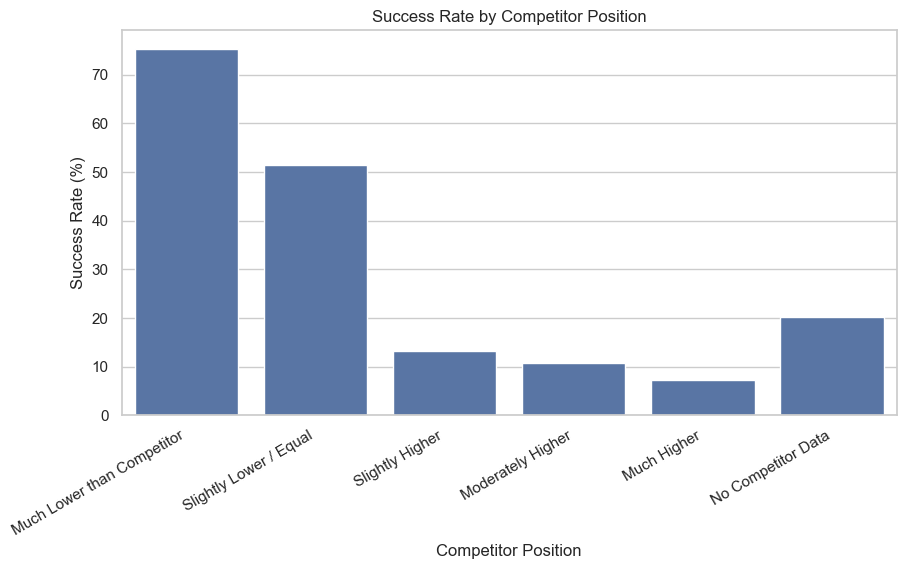

,product,total_rows,total_quote_id,success_rate,avg_unit_price,avg_competitor_price,avg_price_gap_pct,median_price_gap_pct,pct_higher_than_competitor,avg_gmr,avg_qty,avg_subtotal_price,positioning_recommendation
0,A,23,23,13.04,"133,874.43","10,500.00","1,174.99",981.90,100.00,0.26,1.17,"151,126.61",Weak position: review price or strengthen valu...
7,D1,28,28,21.43,"3,308,933.79","2,000,000.00",65.45,49.50,100.00,0.44,1.14,"3,655,740.93",Weak position: review price or strengthen valu...
1,A1,360,358,19.44,"267,957.49","170,000.00",57.62,39.37,99.17,0.38,1.05,"279,116.17",Weak position: review price or strengthen valu...
32,Q,339,339,10.32,"180,838.22","130,000.00",39.11,26.00,99.71,0.17,1.02,"184,512.20",Weak position: review price or strengthen valu...
17,I1,1531,1449,24.10,"289,635.12","240,000.00",20.68,12.12,80.86,0.41,1.25,"338,645.72",Weak position: review price or strengthen valu...
19,J1,73,72,23.29,"741,761.09","620,000.00",19.64,-1.58,47.95,0.36,1.27,"880,977.40",Weak position: review price or strengthen valu...
15,H1,1208,1127,30.71,"399,223.24","360,000.00",10.90,3.24,69.12,0.47,1.24,"474,900.98",Monitor position case by case
35,S,47,46,17.02,"2,083,735.79","1,880,000.00",10.84,1.69,55.32,0.48,1.11,"2,260,109.83",Weak position: review price or strengthen valu...
27,N1,404,382,37.13,"744,368.84","830,000.00",-10.32,-18.24,17.33,0.38,1.16,"862,098.98","Price is competitive, but other factors may re..."
29,O1,62,62,46.77,"741,365.66","830,000.00",-10.68,-20.73,16.13,0.38,1.19,"878,764.40",Strong position: maintain competitive pricing


Output saved as: ../outputs/competitor_positioning_analysis.xlsx


In [9]:
# ============================================================
# COMPETITOR POSITIONING ANALYSIS
# Assumption:
# - df is already loaded from df_preprocessed.csv
# - convert_to_order = 0 means Success
# - convert_to_order = 1 means Fail
# - preprocessing features already exist
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)
sns.set(style="whitegrid")

# ============================================================
# 1. Use existing preprocessed dataframe
# If df is not loaded yet, uncomment this:
# df = pd.read_csv("df_preprocessed.csv")
# ============================================================

print("Dataset shape:", df.shape)
print(df.columns.tolist())

# ============================================================
# 2. Helper columns only for this task
# Not preprocessing, only for easier interpretation
# ============================================================

if "success" not in df.columns:
    df["success"] = np.where(df["convert_to_order"] == 0, 1, 0)

if "fail" not in df.columns:
    df["fail"] = np.where(df["convert_to_order"] == 1, 1, 0)

if "conversion_label" not in df.columns:
    df["conversion_label"] = df["convert_to_order"].map({
        0: "Success",
        1: "Fail"
    })

# ============================================================
# 3. Set competitor column names
# This handles different possible names from preprocessing
# ============================================================

avg_comp_col = "avg_competitor_price" if "avg_competitor_price" in df.columns else "avg_compe_price"
min_comp_col = "min_competitor_price" if "min_competitor_price" in df.columns else "min_compe_price"
max_comp_col = "max_competitor_price" if "max_competitor_price" in df.columns else "max_compe_price"

gap_avg_col = "price_gap_avg_competitor_pct"
gap_min_col = "price_gap_min_competitor_pct"

print("Average competitor price column:", avg_comp_col)
print("Minimum competitor price column:", min_comp_col)
print("Maximum competitor price column:", max_comp_col)

# ============================================================
# 4. Create competitor position category
# This classifies whether our price is lower, similar, or higher
# than the average competitor price.
# ============================================================

def classify_price_position(row):
    gap = row[gap_avg_col]

    if pd.isna(gap):
        return "No Competitor Data"
    elif gap < -10:
        return "Much Lower than Competitor"
    elif -10 <= gap <= 0:
        return "Slightly Lower / Equal"
    elif 0 < gap <= 10:
        return "Slightly Higher"
    elif 10 < gap <= 30:
        return "Moderately Higher"
    else:
        return "Much Higher"

df["competitor_position"] = df.apply(classify_price_position, axis=1)

display(df[[
    "quote_id",
    "product",
    "unit_price",
    avg_comp_col,
    gap_avg_col,
    "competitor_position",
    "convert_to_order",
    "conversion_label"
]].head())

# ============================================================
# 5. Overall competitor positioning summary
# ============================================================

position_summary = df.groupby("competitor_position").agg(
    total_rows=("competitor_position", "count"),
    total_quote_id=("quote_id", "nunique"),
    success_rate=("success", "mean"),
    fail_rate=("fail", "mean"),
    avg_unit_price=("unit_price", "mean"),
    avg_competitor_price=(avg_comp_col, "mean"),
    avg_price_gap_pct=(gap_avg_col, "mean"),
    median_price_gap_pct=(gap_avg_col, "median"),
    avg_gmr=("gross_margin_rate", "mean"),
    avg_qty=("qty", "mean"),
    avg_subtotal_price=("subtotal_price", "mean")
).reset_index()

position_summary["success_rate"] = position_summary["success_rate"] * 100
position_summary["fail_rate"] = position_summary["fail_rate"] * 100

position_order = [
    "Much Lower than Competitor",
    "Slightly Lower / Equal",
    "Slightly Higher",
    "Moderately Higher",
    "Much Higher",
    "No Competitor Data"
]

position_summary["competitor_position"] = pd.Categorical(
    position_summary["competitor_position"],
    categories=position_order,
    ordered=True
)

position_summary = position_summary.sort_values("competitor_position")

display(position_summary)

# ============================================================
# 6. Visualization: Success rate by competitor position
# ============================================================

plt.figure(figsize=(11, 5))
sns.barplot(
    data=position_summary,
    x="competitor_position",
    y="success_rate"
)

plt.title("Success Rate by Competitor Price Position")
plt.xlabel("Competitor Price Position")
plt.ylabel("Success Rate (%)")
plt.xticks(rotation=30, ha="right")
plt.show()

# ============================================================
# 7. Boxplot: price gap by conversion outcome
# ============================================================

plot_data = df.dropna(subset=[gap_avg_col]).copy()

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=plot_data,
    x="conversion_label",
    y=gap_avg_col
)

plt.axhline(0, linestyle="--")
plt.title("Price Gap vs Average Competitor by Conversion Outcome")
plt.xlabel("Conversion Outcome")
plt.ylabel("Price Gap vs Avg Competitor (%)")
plt.show()

# ============================================================
# 8. Product-level competitor positioning
# This shows which products are more expensive or cheaper
# compared to competitors.
# ============================================================

product_competitor_summary = df.groupby("product").agg(
    total_rows=("product", "count"),
    total_quote_id=("quote_id", "nunique"),
    success_rate=("success", "mean"),
    avg_unit_price=("unit_price", "mean"),
    avg_competitor_price=(avg_comp_col, "mean"),
    avg_price_gap_pct=(gap_avg_col, "mean"),
    median_price_gap_pct=(gap_avg_col, "median"),
    pct_higher_than_competitor=("higher_than_avg_competitor", "mean"),
    avg_gmr=("gross_margin_rate", "mean"),
    avg_qty=("qty", "mean"),
    avg_subtotal_price=("subtotal_price", "mean")
).reset_index()

product_competitor_summary["success_rate"] = (
    product_competitor_summary["success_rate"] * 100
)

product_competitor_summary["pct_higher_than_competitor"] = (
    product_competitor_summary["pct_higher_than_competitor"] * 100
)

display(product_competitor_summary.sort_values(
    "avg_price_gap_pct",
    ascending=False
))

# ============================================================
# 9. Reliable product competitor positioning
# Filter products with enough records
# ============================================================

MIN_PRODUCT_ROWS = 20

reliable_product_competitor = product_competitor_summary[
    product_competitor_summary["total_rows"] >= MIN_PRODUCT_ROWS
].copy()

display(reliable_product_competitor.sort_values(
    "avg_price_gap_pct",
    ascending=False
))

# ============================================================
# 10. Visualization: Average price gap by product
# Positive value means our price is higher than average competitor.
# Negative value means our price is lower than average competitor.
# ============================================================

plt.figure(figsize=(12, 6))
sns.barplot(
    data=reliable_product_competitor.sort_values("avg_price_gap_pct", ascending=False),
    x="product",
    y="avg_price_gap_pct"
)

plt.axhline(0, linestyle="--")
plt.title("Average Price Gap vs Competitor by Product")
plt.xlabel("Product")
plt.ylabel("Average Price Gap vs Avg Competitor (%)")
plt.xticks(rotation=45)
plt.show()

# ============================================================
# 11. Product x competitor position summary
# This shows product-level success rate under each price position.
# ============================================================

product_position_summary = df.groupby(["product", "competitor_position"]).agg(
    total_rows=("product", "count"),
    total_quote_id=("quote_id", "nunique"),
    success_rate=("success", "mean"),
    fail_rate=("fail", "mean"),
    avg_unit_price=("unit_price", "mean"),
    avg_competitor_price=(avg_comp_col, "mean"),
    avg_price_gap_pct=(gap_avg_col, "mean"),
    avg_gmr=("gross_margin_rate", "mean"),
    avg_qty=("qty", "mean"),
    avg_subtotal_price=("subtotal_price", "mean")
).reset_index()

product_position_summary["success_rate"] = product_position_summary["success_rate"] * 100
product_position_summary["fail_rate"] = product_position_summary["fail_rate"] * 100

display(product_position_summary.sort_values(
    ["product", "competitor_position"]
))

# ============================================================
# 12. Reliable product x competitor position summary
# ============================================================

MIN_GROUP_ROWS = 5

reliable_product_position = product_position_summary[
    (product_position_summary["product"].isin(reliable_product_competitor["product"])) &
    (product_position_summary["total_rows"] >= MIN_GROUP_ROWS)
].copy()

display(reliable_product_position.sort_values(
    ["product", "success_rate"],
    ascending=[True, False]
))

# ============================================================
# 13. Heatmap: Success rate by product and competitor position
# ============================================================

heatmap_data = reliable_product_position.pivot_table(
    index="product",
    columns="competitor_position",
    values="success_rate",
    aggfunc="mean"
)

heatmap_data = heatmap_data.reindex(columns=position_order)

plt.figure(figsize=(13, 8))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)

plt.title("Success Rate by Product and Competitor Price Position")
plt.xlabel("Competitor Price Position")
plt.ylabel("Product")
plt.show()

# ============================================================
# 14. Competitor position summary only
# ============================================================

competitor_position_summary = df.groupby("competitor_position").agg(
    total_rows=("quote_id", "count"),
    total_quote_id=("quote_id", "nunique"),
    success_rate=("success", "mean"),
    avg_gmr=("gross_margin_rate", "mean"),
    avg_price_gap_pct=(gap_avg_col, "mean")
).reset_index()

competitor_position_summary["success_rate"] = (
    competitor_position_summary["success_rate"] * 100
)

competitor_position_summary["competitor_position"] = pd.Categorical(
    competitor_position_summary["competitor_position"],
    categories=position_order,
    ordered=True
)

competitor_position_summary = competitor_position_summary.sort_values(
    "competitor_position"
)

display(competitor_position_summary)

# ============================================================
# 15. Visualization: Success rate by competitor position only
# ============================================================

plt.figure(figsize=(10, 5))

sns.barplot(
    data=competitor_position_summary,
    x="competitor_position",
    y="success_rate",
    order=position_order
)

plt.title("Success Rate by Competitor Position")
plt.xlabel("Competitor Position")
plt.ylabel("Success Rate (%)")
plt.xticks(rotation=30, ha="right")
plt.show()

# ============================================================
# 16. Create final competitor positioning recommendation table
# ============================================================

def competitor_position_recommendation(row):
    success_rate = row["success_rate"]
    price_gap = row["avg_price_gap_pct"]

    if pd.isna(price_gap):
        return "Competitor data is limited; improve competitor price collection"
    elif price_gap <= 0 and success_rate >= 40:
        return "Strong position: maintain competitive pricing"
    elif price_gap <= 0 and success_rate < 40:
        return "Price is competitive, but other factors may reduce success"
    elif price_gap > 0 and success_rate >= 40:
        return "Potential premium position: justify higher price with value/service"
    elif price_gap > 0 and success_rate < 30:
        return "Weak position: review price or strengthen value proposition"
    else:
        return "Monitor position case by case"


competitor_position_final = reliable_product_competitor.copy()

competitor_position_final["positioning_recommendation"] = competitor_position_final.apply(
    competitor_position_recommendation,
    axis=1
)

display(competitor_position_final.sort_values(
    ["avg_price_gap_pct", "success_rate"],
    ascending=[False, False]
))

# ============================================================
# 17. Save output
# ============================================================

output_file = "../outputs/competitor_positioning_analysis.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    position_summary.to_excel(writer, sheet_name="Overall_Position", index=False)
    product_competitor_summary.to_excel(writer, sheet_name="Product_Position", index=False)
    reliable_product_competitor.to_excel(writer, sheet_name="Reliable_Product_Position", index=False)
    product_position_summary.to_excel(writer, sheet_name="Product_x_Position", index=False)
    reliable_product_position.to_excel(writer, sheet_name="Reliable_Product_x_Position", index=False)
    competitor_position_summary.to_excel(writer, sheet_name="Competitor_Position", index=False)
    competitor_position_final.to_excel(writer, sheet_name="Final_Recommendation", index=False)

print(f"Output saved as: {output_file}")

## 5. Data quality and exception detection

In [10]:
# ============================================================
# DATA QUALITY AND EXCEPTION DETECTION
#
# Assumption:
# - df is already loaded from df_preprocessed.csv
# - preprocessing has already been done
# - this task only detects relevant issues/exceptions
# ============================================================

import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

print("Dataset shape:", df.shape)

# ============================================================
# 1. Prepare issue collector
# ============================================================

issue_list = []

def add_issue(data, issue_type, severity, description):
    if len(data) > 0:
        temp = data.copy()
        temp["issue_type"] = issue_type
        temp["severity"] = severity
        temp["issue_description"] = description
        issue_list.append(temp)

# ============================================================
# 2. Missing value summary for important columns
# ============================================================

key_cols = [
    "quote_id",
    "product",
    "kw",
    "unit_price",
    "qty",
    "subtotal_price",
    "gross_margin_rate",
    "convert_to_order",
    "energy_grant_amount",
    "competitor_a",
    "competitor_b",
    "competitor_c",
    "avg_compe_price",
    "price_gap_avg_competitor_pct"
]

key_cols = [col for col in key_cols if col in df.columns]

missing_summary = pd.DataFrame({
    "column": key_cols,
    "missing_count": df[key_cols].isna().sum().values,
    "missing_percentage": (df[key_cols].isna().mean() * 100).values
}).sort_values("missing_count", ascending=False)

display(missing_summary)

# ============================================================
# 3. Repeated Quote ID summary
# Repeated Quote ID is not always an error.
# It can mean one quote contains multiple products.
# ============================================================

quote_id_summary = df.groupby("quote_id").agg(
    row_count=("quote_id", "count"),
    product_count=("product", "nunique"),
    unit_price_count=("unit_price", "nunique"),
    qty_count=("qty", "nunique"),
    outcome_count=("convert_to_order", "nunique")
).reset_index()

repeated_quote_ids = quote_id_summary[
    quote_id_summary["row_count"] > 1
].copy()

display(repeated_quote_ids.sort_values("row_count", ascending=False))

# ============================================================
# 4. Same Quote ID + Product + Unit Price repeated
# This should NOT be dropped.
# We only flag it for review.
# ============================================================

same_quote_product_price_repeat = df.groupby(
    ["quote_id", "product", "unit_price"]
).agg(
    row_count=("quote_id", "count"),
    qty_count=("qty", "nunique"),
    subtotal_count=("subtotal_price", "nunique"),
    outcome_count=("convert_to_order", "nunique")
).reset_index()

same_quote_product_price_repeat = same_quote_product_price_repeat[
    same_quote_product_price_repeat["row_count"] > 1
]

detail_same_quote_product_price_repeat = df.merge(
    same_quote_product_price_repeat[["quote_id", "product", "unit_price"]],
    on=["quote_id", "product", "unit_price"],
    how="inner"
).sort_values(["quote_id", "product", "unit_price"])

add_issue(
    detail_same_quote_product_price_repeat,
    issue_type="Repeated same Quote ID, Product, and Unit Price",
    severity="Low",
    description="Same quote, product, and unit price appear multiple times. Kept as requested, but should be reviewed as repeated line items."
)

print("Repeated same Quote ID + Product + Unit Price rows:", len(detail_same_quote_product_price_repeat))
display(detail_same_quote_product_price_repeat.head())

# ============================================================
# 5. Quantity issue check
# From interview: Qty = 0 is system error.
# It should already be removed, but we check again.
# ============================================================

qty_zero = df[df["qty"] == 0].copy()
qty_negative = df[df["qty"] < 0].copy()

add_issue(
    qty_zero,
    issue_type="Quantity equals zero",
    severity="High",
    description="Quantity = 0 was confirmed as a system error."
)

add_issue(
    qty_negative,
    issue_type="Negative quantity",
    severity="High",
    description="Quantity is negative and likely a data error."
)

print("Qty = 0 rows:", len(qty_zero))
print("Qty < 0 rows:", len(qty_negative))

# ============================================================
# 6. Subtotal mismatch check
# Expected subtotal = unit_price * qty
# ============================================================

df["expected_subtotal_check"] = df["unit_price"] * df["qty"]
df["subtotal_diff_check"] = df["subtotal_price"] - df["expected_subtotal_check"]

tolerance = 1

subtotal_mismatch = df[
    df["subtotal_diff_check"].abs() > tolerance
].copy()

add_issue(
    subtotal_mismatch,
    issue_type="Subtotal mismatch",
    severity="High",
    description="Subtotal price does not match Unit Price x Qty."
)

print("Subtotal mismatch rows:", len(subtotal_mismatch))

display(subtotal_mismatch[[
    "quote_id",
    "product",
    "unit_price",
    "qty",
    "subtotal_price",
    "expected_subtotal_check",
    "subtotal_diff_check",
    "convert_to_order"
]].head())
# ============================================================
# 7. Gross Margin Rate exception check
# Negative GMR can be valid, but should be reviewed separately.
# ============================================================

negative_gmr = df[df["gross_margin_rate"] < 0].copy()
extreme_high_gmr = df[df["gross_margin_rate"] > 1].copy()
extreme_low_gmr = df[df["gross_margin_rate"] < -1].copy()

add_issue(
    negative_gmr,
    issue_type="Negative Gross Margin Rate",
    severity="Business Exception",
    description="Negative GMR may be valid as strategic loss pricing, but should be reviewed separately."
)

add_issue(
    extreme_high_gmr,
    issue_type="Extreme high Gross Margin Rate",
    severity="Medium",
    description="Gross Margin Rate is above 100%. Review margin calculation."
)

add_issue(
    extreme_low_gmr,
    issue_type="Extreme low Gross Margin Rate",
    severity="Medium",
    description="Gross Margin Rate is below -100%. Review margin calculation."
)

print("Negative GMR rows:", len(negative_gmr))
print("GMR > 100% rows:", len(extreme_high_gmr))
print("GMR < -100% rows:", len(extreme_low_gmr))

# ============================================================
# 8. Competitor data availability
# Missing competitor data is not always an error,
# but it limits competitor positioning analysis.
# ============================================================

competitor_cols = ["competitor_a", "competitor_b", "competitor_c"]
competitor_cols = [col for col in competitor_cols if col in df.columns]

no_competitor_data = df[
    df[competitor_cols].isna().sum(axis=1) == len(competitor_cols)
].copy()

partial_competitor_data = df[
    (df[competitor_cols].isna().sum(axis=1) > 0) &
    (df[competitor_cols].isna().sum(axis=1) < len(competitor_cols))
].copy()

add_issue(
    no_competitor_data,
    issue_type="No competitor price available",
    severity="Business Limitation",
    description="No competitor price is available, so competitor positioning cannot be calculated."
)

add_issue(
    partial_competitor_data,
    issue_type="Partial competitor price available",
    severity="Low",
    description="Only some competitor prices are available, so competitor positioning is based on incomplete benchmark data."
)

print("No competitor data rows:", len(no_competitor_data))
print("Partial competitor data rows:", len(partial_competitor_data))

# ============================================================
# 9. Competitor B = 900,000 but not 75 Kw
# From interview: Competitor B = 900,000 is related to 75 Kw.
# ============================================================

if "competitor_b" in df.columns and "kw" in df.columns:
    comp_b_900_not_75kw = df[
        (df["competitor_b"] == 900000) &
        (df["kw"] != 75)
    ].copy()

    add_issue(
        comp_b_900_not_75kw,
        issue_type="Competitor B 900,000 not matched with 75 Kw",
        severity="Medium",
        description="Expert mentioned Competitor B = 900,000 is related to 75 Kw. Rows that do not match should be reviewed."
    )

    print("Competitor B = 900,000 but Kw != 75 rows:", len(comp_b_900_not_75kw))

# ============================================================
# 10. Price gap outlier check
# This flags extreme competitor gap values.
# Not always error, but should be reviewed.
# ============================================================

price_gap_col = "price_gap_avg_competitor_pct"

if price_gap_col in df.columns:
    q1 = df[price_gap_col].quantile(0.25)
    q3 = df[price_gap_col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    price_gap_outliers = df[
        (df[price_gap_col] < lower_bound) |
        (df[price_gap_col] > upper_bound)
    ].copy()

    add_issue(
        price_gap_outliers,
        issue_type="Price gap outlier",
        severity="Low",
        description="Price gap vs average competitor is outside the IQR range. Review if the gap is unusually large."
    )

    print("Price gap outlier rows:", len(price_gap_outliers))
    print("Lower bound:", lower_bound)
    print("Upper bound:", upper_bound)

    display(price_gap_outliers[[
        "quote_id",
        "product",
        "unit_price",
        price_gap_col,
        "convert_to_order"
    ]].head())

# ============================================================
# 11. Combine all issue rows
# ============================================================

if len(issue_list) > 0:
    data_quality_issues = pd.concat(issue_list, ignore_index=True)
else:
    data_quality_issues = pd.DataFrame()

print("\n\n\n\n========== ALL ISSUE =========")
print("Total detected issue rows:", len(data_quality_issues))

if len(data_quality_issues) > 0:
    display(data_quality_issues[[
        "issue_type",
        "severity",
        "issue_description",
        "quote_id",
        "product",
        "unit_price",
        "qty",
        "subtotal_price",
        "gross_margin_rate",
        "convert_to_order"
    ]].head(20))

# ============================================================
# 12. Issue summary
# ============================================================

print("\n\n\n\n========== ISSUE SUMMARY =========")

if len(data_quality_issues) > 0:
    issue_summary = data_quality_issues.groupby(
        ["issue_type", "severity", "issue_description"]
    ).agg(
        affected_rows=("quote_id", "count"),
        affected_quote_ids=("quote_id", "nunique")
    ).reset_index()

    issue_summary["affected_row_percentage"] = (
        issue_summary["affected_rows"] / len(df) * 100
    )

    display(issue_summary.sort_values("affected_rows", ascending=False))
else:
    issue_summary = pd.DataFrame()
    print("No issues detected.")

# ============================================================
# 13. High-priority / business exception table
# ============================================================

print("\n\n\n\n========== HIGH PRIORITY =========")

if len(data_quality_issues) > 0:
    high_priority_issues = data_quality_issues[
        data_quality_issues["severity"].isin(["High", "Business Exception"])
    ].copy()

    display(high_priority_issues[[
        "issue_type",
        "severity",
        "quote_id",
        "product",
        "unit_price",
        "qty",
        "subtotal_price",
        "gross_margin_rate",
        "convert_to_order",
        "issue_description"
    ]].head(50))
else:
    high_priority_issues = pd.DataFrame()

# ============================================================
# 14. Save output
# ============================================================

output_file = "../outputs/data_quality_exception_detection.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    missing_summary.to_excel(writer, sheet_name="Missing_Summary", index=False)
    quote_id_summary.to_excel(writer, sheet_name="Quote_ID_Summary", index=False)
    repeated_quote_ids.to_excel(writer, sheet_name="Repeated_Quote_ID", index=False)
    same_quote_product_price_repeat.to_excel(writer, sheet_name="Repeated_Line_Items", index=False)

    if len(data_quality_issues) > 0:
        data_quality_issues.to_excel(writer, sheet_name="All_Issues", index=False)

    if len(issue_summary) > 0:
        issue_summary.to_excel(writer, sheet_name="Issue_Summary", index=False)

    if len(high_priority_issues) > 0:
        high_priority_issues.to_excel(writer, sheet_name="High_Priority_Issues", index=False)

print(f"Output saved as: {output_file}")

Dataset shape: (4991, 40)


,column,missing_count,missing_percentage
11,competitor_c,4934,98.86
10,competitor_b,4525,90.66
9,competitor_a,887,17.77
12,avg_compe_price,830,16.63
13,price_gap_avg_competitor_pct,830,16.63
0,quote_id,0,0.00
5,subtotal_price,0,0.00
4,qty,0,0.00
3,unit_price,0,0.00
2,kw,0,0.00


,quote_id,row_count,product_count,unit_price_count,qty_count,outcome_count
2977,Q-26060,12,1,1,4,1
1613,Q-16146,11,1,2,4,1
2702,Q-23602,10,1,1,4,1
3082,Q-27011,7,1,2,5,1
1555,Q-15773,6,1,1,3,1
...,...,...,...,...,...,...
4582,Q-45103,2,1,1,1,1
4589,Q-45260,2,1,2,1,1
4593,Q-45294,2,2,2,1,1
4626,Q-45710,2,2,2,2,1


Repeated same Quote ID + Product + Unit Price rows: 263


,quote_id,product,kw,unit_price,qty,subtotal_price,gross_margin_rate,convert_to_order,energy_grant_amount,competitor_a,competitor_b,competitor_c,price_order,is_highest_price,is_compe_a,is_compe_b,is_compe_c,known_num_compe,avg_compe_price,max_compe_price,min_compe_price,competitor_count_available,avg_competitor_price,min_competitor_price,max_competitor_price,price_gap_avg_competitor,price_gap_avg_competitor_pct,price_gap_min_competitor,price_gap_min_competitor_pct,higher_than_avg_competitor,is_lower_than_competitor,effective_price_after_grant,grant_ratio_to_subtotal,estimated_cost,estimated_gross_profit,success,fail,conversion_label,margin_group,competitor_position
0,Q-02113,N1,75.00,"718,000.00",2,"1,436,000.00",0.34,0,375000,"760,000.00","900,000.00",NaN,1,1,True,True,False,2,"830,000.00","900,000.00","760,000.00",2,"830,000.00","760,000.00","900,000.00","-112,000.00",-13.49,"-42,000.00",-5.53,0.00,True,"1,061,000.00",0.26,"948,765.20","487,234.80",1,0,Success,30-40%,Much Lower than Competitor
1,Q-02113,N1,75.00,"718,000.00",2,"1,436,000.00",0.34,0,375000,"760,000.00","900,000.00",NaN,2,1,True,True,False,2,"830,000.00","900,000.00","760,000.00",2,"830,000.00","760,000.00","900,000.00","-112,000.00",-13.49,"-42,000.00",-5.53,0.00,True,"1,061,000.00",0.26,"948,765.20","487,234.80",1,0,Success,30-40%,Much Lower than Competitor
2,Q-03409,N1,75.00,"1,283,500.00",1,"1,283,500.00",0.65,1,375000,"760,000.00","900,000.00",NaN,1,1,True,True,False,2,"830,000.00","900,000.00","760,000.00",2,"830,000.00","760,000.00","900,000.00","453,500.00",54.64,"523,500.00",68.88,1.00,False,"908,500.00",0.29,"450,893.55","832,606.45",0,1,Fail,60%+,Much Higher
3,Q-03409,N1,75.00,"1,283,500.00",1,"1,283,500.00",0.65,1,375000,"760,000.00","900,000.00",NaN,2,1,True,True,False,2,"830,000.00","900,000.00","760,000.00",2,"830,000.00","760,000.00","900,000.00","453,500.00",54.64,"523,500.00",68.88,1.00,False,"908,500.00",0.29,"450,893.55","832,606.45",0,1,Fail,60%+,Much Higher
4,Q-05577,E,15.00,"408,100.00",1,"408,100.00",0.60,1,48600,NaN,NaN,NaN,1,1,False,False,False,0,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,"359,500.00",0.12,"163,811.34","244,288.66",0,1,Fail,50-60%,No Competitor Data


...





========== ISSUE SUMMARY =========


,issue_type,severity,issue_description,affected_rows,affected_quote_ids,affected_row_percentage
3,Partial competitor price available,Low,"Only some competitor prices are available, so ...",4161,3877,83.37
2,No competitor price available,Business Limitation,"No competitor price is available, so competito...",830,794,16.63
4,Price gap outlier,Low,Price gap vs average competitor is outside the...,307,304,6.15
5,"Repeated same Quote ID, Product, and Unit Price",Low,"Same quote, product, and unit price appear mul...",263,89,5.27
1,Negative Gross Margin Rate,Business Exception,Negative GMR may be valid as strategic loss pr...,59,50,1.18
0,Extreme low Gross Margin Rate,Medium,Gross Margin Rate is below -100%. Review margi...,1,1,0.02






========== HIGH PRIORITY =========


,issue_type,severity,quote_id,product,unit_price,qty,subtotal_price,gross_margin_rate,convert_to_order,issue_description
263,Negative Gross Margin Rate,Business Exception,Q-05706,Q,"145,340.00",1,"145,340.00",-0.03,0,Negative GMR may be valid as strategic loss pr...
264,Negative Gross Margin Rate,Business Exception,Q-07006,W,"118,001.00",1,"118,001.00",-0.26,0,Negative GMR may be valid as strategic loss pr...
265,Negative Gross Margin Rate,Business Exception,Q-07129,O,"417,550.00",3,"1,252,650.00",-0.00,0,Negative GMR may be valid as strategic loss pr...
266,Negative Gross Margin Rate,Business Exception,Q-07371,K,"282,217.50",1,"282,217.50",-0.08,0,Negative GMR may be valid as strategic loss pr...
267,Negative Gross Margin Rate,Business Exception,Q-07501,Q,"146,900.00",1,"146,900.00",-0.01,1,Negative GMR may be valid as strategic loss pr...
268,Negative Gross Margin Rate,Business Exception,Q-07609,Q,"145,340.00",1,"145,340.00",-0.03,0,Negative GMR may be valid as strategic loss pr...
269,Negative Gross Margin Rate,Business Exception,Q-08029,W,"118,001.00",3,"354,003.00",-0.26,0,Negative GMR may be valid as strategic loss pr...
270,Negative Gross Margin Rate,Business Exception,Q-08456,Q,"147,680.00",1,"147,680.00",-0.01,1,Negative GMR may be valid as strategic loss pr...
271,Negative Gross Margin Rate,Business Exception,Q-08521,Q,"146,900.00",2,"293,800.00",-0.01,1,Negative GMR may be valid as strategic loss pr...
272,Negative Gross Margin Rate,Business Exception,Q-08582,Q,"146,900.00",1,"146,900.00",-0.01,1,Negative GMR may be valid as strategic loss pr...


Output saved as: ../outputs/data_quality_exception_detection.xlsx
